# Clustering des Recettes 

**Objectif** : Regrouper les recettes par similarité de processus culinaire en suivant **exactement** les 7 étapes du plan.

**Pipeline** :
1. Charger les séquences d'actions
2. TF-IDF sur les verbes
3. PCA à ~50 dimensions
4. Tester K=3..15 avec méthode du coude + silhouette
5. K-Means avec K optimal
6. Analyser les clusters (verbes dominants, tailles)
7. Visualiser (scatter 2D)

**Résultat attendu** : clusters naturels émergents (pâtisseries, mijotés, salades, etc.) — **sans règles manuelles**.

## Cellule 1 — Chargement des données

In [ ]:
import pandas as pd
import numpy as np
import ast
from collections import Counter
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_PATH = "data_wide_with_clusters.csv" # data wide que je modifie pour repartir 
df = pd.read_csv(DATA_PATH)

# On ignore la colonne cluster existante (on va la recreer proprement)- dataset venant du premiere essaie de creation de clusters qui etait 
# Faux. Donc j'ai juste juste repris data_wide et j'ai drop la colonne cluster pour repartir sur de bonne base.
if 'cluster' in df.columns:
    df = df.drop(columns=['cluster'])
    print("Ancienne colonne 'cluster' supprimee.")

gestes = "actions_principale"
def parse_seq(val):
    if isinstance(val, list):
        return val
    try:
        return ast.literal_eval(val)
    except Exception:
        return str(val).split()

df[gestes] = df[gestes].apply(parse_seq)

# Transformer chaque sequence en une chaine (requis par TF-IDF)
df['actions_str'] = df[gestes].apply(lambda seq: ' '.join(seq))

print(f"Dataset charge : {len(df):,} recettes")
print(f"Exemple sequence : {df['actions_str'].iloc[0][:100]}...")

Ancienne colonne 'cluster' supprimee.
Dataset charge : 34,591 recettes
Exemple sequence : sift heat beat chill shape bake cool mix dip...


## Cellule 2 — Vectorisation TF-IDF

**Principe** : TF-IDF donne plus de poids aux verbes **rares et spécifiques** (ex: `flamber`, `caramelize`) et moins de poids aux verbes **communs** (ex: `mix`, `serve`).

**Paramètres** :
- `min_df=5` : un verbe doit apparaître dans au moins 5 recettes (élimine les verbes rarissimes qui sont du bruit)
- `max_df=0.9` : un verbe doit apparaître dans moins de 90% des recettes (élimine les verbes omniprésents sans info)

In [2]:
vectorizer = TfidfVectorizer(
    min_df=5,
    max_df=0.9,
    token_pattern=r'(?u)\b\w+\b'
)

X_tfidf = vectorizer.fit_transform(df['actions_str'])
print(f"Matrice TF-IDF : {X_tfidf.shape}")
print(f"Nombre de verbes retenus : {len(vectorizer.get_feature_names_out())}")
print(f"Exemples de verbes : {list(vectorizer.get_feature_names_out()[:20])}")

Matrice TF-IDF : (34591, 344)
Nombre de verbes retenus : 344
Exemples de verbes : ['add', 'adjust', 'apply', 'arrange', 'assemble', 'attach', 'bake', 'bash', 'baste', 'beat', 'bend', 'blanch', 'blend', 'blitz', 'blot', 'boil', 'bottle', 'braid', 'braise', 'break']


## Cellule 3 — Réduction de dimensionnalité (PCA)

**Pourquoi PCA** : K-Means fonctionne mal en haute dimension ("curse of dimensionality"). On réduit à ~50 composantes principales qui capturent la variance essentielle.

On affiche la **variance expliquée cumulative** pour vérifier qu'on garde assez d'information.

In [3]:
N_COMPOSANTES = 50
pca = PCA(n_components=N_COMPOSANTES, random_state=42)
X_reduced = pca.fit_transform(X_tfidf.toarray())

variance_cumulee = np.cumsum(pca.explained_variance_ratio_)
print(f"Matrice reduite : {X_reduced.shape}")
print(f"Variance expliquee par {N_COMPOSANTES} composantes : {variance_cumulee[-1]*100:.1f}%")
print(f"Variance a 10 composantes : {variance_cumulee[9]*100:.1f}%")
print(f"Variance a 30 composantes : {variance_cumulee[29]*100:.1f}%")

Matrice reduite : (34591, 50)
Variance expliquee par 50 composantes : 70.8%
Variance a 10 composantes : 35.3%
Variance a 30 composantes : 57.8%


## Cellule 4 — Choix du K optimal (Elbow + Silhouette)

On teste **K de 3 à 15** et on calcule pour chaque K :
- **Inertie** : somme des distances intra-cluster → méthode du coude
- **Score silhouette** : qualité de séparation [−1, 1] (plus proche de 1 = mieux)

Silhouette calculée sur un échantillon de 5000 recettes (trop lent sur 34K).

Le **K optimal** est celui où l'inertie commence à plateau ("coude") ET où la silhouette est maximale.

K          Inertie   Silhouette
--------------------------------
3            18064       0.1130
4            17341       0.1194
5            16788       0.1129
6            16230       0.1031
7            15971       0.1056
8            15273       0.1290
9            14736       0.1335
10           14388       0.1363
11           14178       0.1480
12           13827       0.1413
13           13579       0.1538
14           13280       0.1574
15           12898       0.1673
16           12765       0.1654
17           12492       0.1706
18           12414       0.1637
19           12202       0.1733
20           11953       0.1787
21           11804       0.1811
22           11406       0.1952
23           11420       0.1897
24           11233       0.1943
25           11163       0.1867


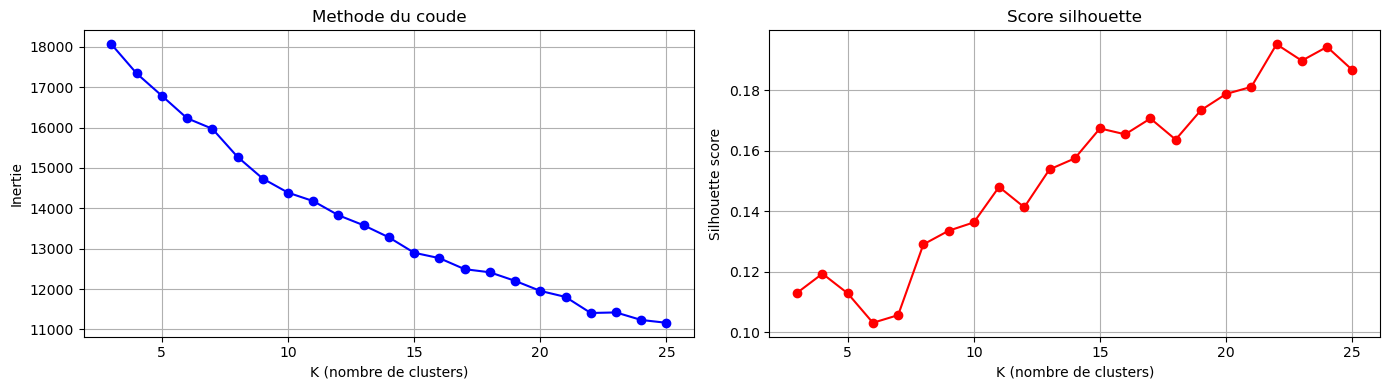


K optimal (silhouette max) : 22


In [4]:
Ks = list(range(3, 26))  # de 3 a 25 inclus
inerties = []
silhouettes = []

np.random.seed(42)
idx_sample = np.random.choice(len(X_reduced), size=5000, replace=False)
X_sample = X_reduced[idx_sample]

print(f"{'K':<5} {'Inertie':>12} {'Silhouette':>12}")
print("-" * 32)
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reduced)
    inerties.append(km.inertia_)
    labels_sample = labels[idx_sample]
    sil = silhouette_score(X_sample, labels_sample)
    silhouettes.append(sil)
    print(f"{k:<5} {km.inertia_:>12.0f} {sil:>12.4f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(Ks, inerties, 'bo-')
axes[0].set_xlabel('K (nombre de clusters)')
axes[0].set_ylabel('Inertie')
axes[0].set_title('Methode du coude')
axes[0].grid(True)

axes[1].plot(Ks, silhouettes, 'ro-')
axes[1].set_xlabel('K (nombre de clusters)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Score silhouette')
axes[1].grid(True)
plt.tight_layout()
plt.show()

k_opt = Ks[int(np.argmax(silhouettes))]
print(f"\nK optimal (silhouette max) : {k_opt}")

## Cellule 5 — Clustering final avec K optimal ou maximale

In [ ]:
K_FINAL = 25  # TEST : on prend 25 pour avoir des clusters plus petits et plus nombreux, ce qui est plus interessant pour l'analyse qualitative.
print(f"K final utilise : {K_FINAL}")

km = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_reduced)

distribution = df['cluster'].value_counts().sort_index()
print(f"\nDistribution des clusters :")
for c, count in distribution.items():
    pct = 100 * count / len(df)
    print(f"  Cluster {c:>2} : {count:>6,} recettes ({pct:>5.1f}%)")

print(f"\nPlus gros cluster : {distribution.max():,} recettes ({100*distribution.max()/len(df):.1f}%)")
print(f"Plus petit cluster : {distribution.min():,} recettes ({100*distribution.min()/len(df):.1f}%)")

K final utilise : 25

Distribution des clusters :
  Cluster  0 :    709 recettes (  2.0%)
  Cluster  1 :  1,009 recettes (  2.9%)
  Cluster  2 :  1,074 recettes (  3.1%)
  Cluster  3 :    795 recettes (  2.3%)
  Cluster  4 :  1,836 recettes (  5.3%)
  Cluster  5 :    877 recettes (  2.5%)
  Cluster  6 :    963 recettes (  2.8%)
  Cluster  7 :  1,213 recettes (  3.5%)
  Cluster  8 :  1,190 recettes (  3.4%)
  Cluster  9 :  1,142 recettes (  3.3%)
  Cluster 10 :    890 recettes (  2.6%)
  Cluster 11 :  1,074 recettes (  3.1%)
  Cluster 12 :  1,222 recettes (  3.5%)
  Cluster 13 :  2,527 recettes (  7.3%)
  Cluster 14 :  4,676 recettes ( 13.5%)
  Cluster 15 :  1,802 recettes (  5.2%)
  Cluster 16 :  1,490 recettes (  4.3%)
  Cluster 17 :  1,618 recettes (  4.7%)
  Cluster 18 :  1,494 recettes (  4.3%)
  Cluster 19 :  1,081 recettes (  3.1%)
  Cluster 20 :  1,342 recettes (  3.9%)
  Cluster 21 :    748 recettes (  2.2%)
  Cluster 22 :  2,488 recettes (  7.2%)
  Cluster 23 :    567 recettes

## Cellule 6 — Analyse des clusters (verbes dominants + exemples)

Pour chaque cluster :
- Top 10 des verbes caractéristiques (poids TF-IDF moyen dans le cluster)
- 5 exemples de titres
- Répartition des catégories culinaires

In [6]:
feature_names = vectorizer.get_feature_names_out()
X_dense = X_tfidf.toarray()

for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    taille = mask.sum()
    
    tfidf_moy = X_dense[mask.values].mean(axis=0)
    top_idx = np.argsort(tfidf_moy)[::-1][:10]
    top_verbes = [(feature_names[i], tfidf_moy[i]) for i in top_idx]
    
    cat_dist = df[mask]['category'].value_counts().head(3).to_dict() if 'category' in df.columns else {}
    
    print(f"\n{'='*70}")
    print(f"CLUSTER {c} — {taille:,} recettes ({100*taille/len(df):.1f}%)")
    print(f"{'='*70}")
    print(f"Top verbes : {', '.join([f'{v}({p:.3f})' for v, p in top_verbes])}")
    print(f"Categories : {cat_dist}")
    if 'title' in df.columns:
        exemples = df[mask]['title'].head(5).tolist()
        print(f"Exemples :")
        for t in exemples:
            print(f"  - {t}")


CLUSTER 0 — 709 recettes (2.0%)
Top verbes : toast(0.538), serve(0.115), chop(0.103), mix(0.090), toss(0.080), spread(0.063), cook(0.057), heat(0.054), sprinkle(0.043), season(0.043)
Categories : {'other': 332, 'quick_prep': 246, 'bakery': 86}
Exemples :
  - Chipotle Grilled Chicken with Avocado Sandwich
  - The Ultimate BLT Sandwich
  - Southwestern Burgers
  - Butter Shrimp Recipe
  - Apple and Toasted Pecan Salad With Honey Poppy Seed Dressing

CLUSTER 1 — 1,009 recettes (2.9%)
Top verbes : bake(0.546), heat(0.389), chop(0.313), mix(0.311), serve(0.263), cool(0.086), sprinkle(0.046), fill(0.027), saute(0.022), layer(0.020)
Categories : {'other': 462, 'bakery': 326, 'stew': 173}
Exemples :
  - Broccoli Rice With Cheese Casserole
  - Cranberry-chocolate Crumble Dessert
  - Lemon-Raspberry Muffins - Gluten Free or Regular
  - Apple Date Crisp
  - Garlic and Dill Salmon

CLUSTER 2 — 1,074 recettes (3.1%)
Top verbes : fry(0.503), drain(0.157), heat(0.136), serve(0.130), chop(0.116), mix

## Cellule 7 — Visualisation 2D des clusters

PCA à 2 dimensions pour voir la séparation visuelle.

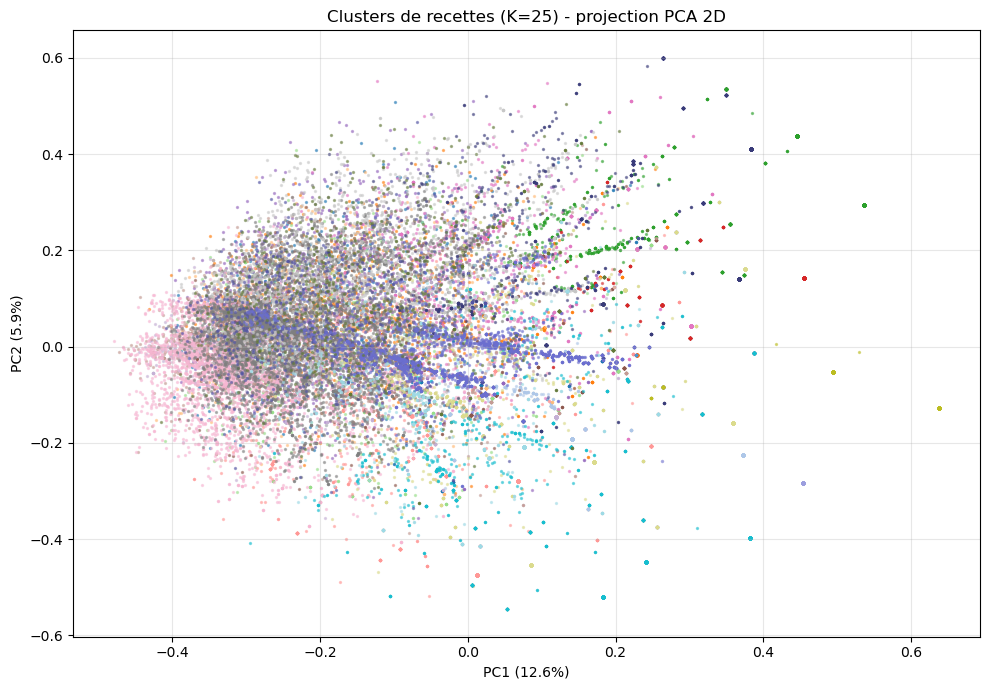


Couleurs HEX des clusters
  cluster  0 : #1f77b4
  cluster  1 : #aec7e8
  cluster  2 : #ff7f0e
  cluster  3 : #ffbb78
  cluster  4 : #2ca02c
  cluster  5 : #98df8a
  cluster  6 : #d62728
  cluster  7 : #ff9896
  cluster  8 : #9467bd
  cluster  9 : #c5b0d5
  cluster 10 : #8c564b
  cluster 11 : #c49c94
  cluster 12 : #e377c2
  cluster 13 : #f7b6d2
  cluster 14 : #7f7f7f
  cluster 15 : #c7c7c7
  cluster 16 : #bcbd22
  cluster 17 : #dbdb8d
  cluster 18 : #17becf
  cluster 19 : #9edae5
  cluster 20 : #393b79
  cluster 21 : #5254a3
  cluster 22 : #6b6ecf
  cluster 23 : #9c9ede
  cluster 24 : #637939


In [7]:
import matplotlib.colors as mcolors
import os

os.makedirs('img', exist_ok=True)

pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_reduced)

# 25 couleurs distinctes (tab20 + 5 premieres de tab20b)
colors_25 = list(plt.cm.tab20.colors) + list(plt.cm.tab20b.colors[:5])
cluster_colors = {c: colors_25[c] for c in range(25)}

# ── Plot SANS legende (la legende sera dans Streamlit)
plt.figure(figsize=(10, 7))
for c in sorted(df['cluster'].unique()):
    mask = df['cluster'] == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], s=2, alpha=0.5,
                color=cluster_colors[c])
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
plt.title(f'Clusters de recettes (K={K_FINAL}) - projection PCA 2D')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('img/clustering_pca_2d.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Imprimer les couleurs en HEX pour usage dans Streamlit
print('\nCouleurs HEX des clusters')
for c in range(25):
    hex_color = mcolors.to_hex(cluster_colors[c])
    print(f"  cluster {c:2d} : {hex_color}")

## Cellule 8 — Sauvegarde des clusters K=25 dans le CSV

On écrase la colonne `cluster` existante dans `data_wide_with_clusters.csv` avec les nouveaux clusters K=25. Ainsi la Stratégie 1 (Trie) et Stratégie 3 (Random Forest) pourront utiliser ces clusters directement.

In [8]:
# Recharger le CSV original pour recuperer toutes les colonnes
df_full = pd.read_csv(DATA_PATH)

# Retirer l'ancienne colonne cluster si elle existe
if 'cluster' in df_full.columns:
    df_full = df_full.drop(columns=['cluster'])
    print("Ancienne colonne 'cluster' supprimee.")

# Injecter les nouveaux clusters K=25 via l'id (merge plus robuste que l'index)
clusters_map = df[['id', 'cluster']].copy()
df_full = df_full.merge(clusters_map, on='id', how='left')

# Verifications
print(f"Nombre de recettes : {len(df_full):,}")
print(f"Nombre de recettes sans cluster assigne : {df_full['cluster'].isna().sum()}")
print(f"Colonnes finales : {list(df_full.columns)}")

# Sauvegarde (ecrase le fichier existant)
df_full.to_csv(DATA_PATH, index=False)
print(f"\nFichier sauvegarde : {DATA_PATH}")
print(f"Distribution des clusters :")
print(df_full['cluster'].value_counts().sort_index())

Ancienne colonne 'cluster' supprimee.
Nombre de recettes : 34,591
Nombre de recettes sans cluster assigne : 0
Colonnes finales : ['id', 'variante_principale', 'variante_ingredients', 'variante_permutation', 'actions_principale', 'actions_ingredients', 'actions_permutation', 'nb_principale', 'nb_ingredients', 'nb_permutation', 'title', 'category', 'number_of_steps', 'number_of_ingredients', 'complexity', 'flag_t6_complet', 'flag_t6_doublon', 'flag_t6_vide', 'flag_t6_anti_dup', 'flag_t6_global', 'cluster']

Fichier sauvegarde : data_wide_with_clusters.csv
Distribution des clusters :
cluster
0      709
1     1009
2     1074
3      795
4     1836
5      877
6      963
7     1213
8     1190
9     1142
10     890
11    1074
12    1222
13    2527
14    4676
15    1802
16    1490
17    1618
18    1494
19    1081
20    1342
21     748
22    2488
23     567
24     764
Name: count, dtype: int64


fin du clustering
- Note : data_wide n'est pas enregistrer dans le fichier, mais il est en memoire. dans execution. Je n'avais pas assez de place pour me permettre d'avoir data_wide et data_wide_clusters dans le meme fichier. 